#Imortando Datos

In [15]:
import pandas as pd
from google.colab import drive


drive.mount('/content/drive')


df = pd.read_csv('/content/drive/My Drive/telecom_x_limpio.csv')

print(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  Streami

#Eliminación de Columnas Irrelevantes

In [16]:
import pandas as pd

df = df.drop(columns=['customerID', 'Churn'])


print("Columnas actuales en el dataset:")
print(df.columns.tolist())

Columnas actuales en el dataset:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Pago_Automatico', 'Contrato_Mensual', 'Cuentas_Diarias', 'Churn_Num', 'Cant_Servicios']


#Encoding

In [17]:

columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()


df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

columnas_booleanas = df_encoded.select_dtypes(include=['bool']).columns.tolist()
for col in columnas_booleanas:
    df_encoded[col] = df_encoded[col].astype(int)

ruta_guardado = '/content/drive/My Drive/telecom_x_encoded.csv'
df_encoded.to_csv(ruta_guardado, index=False)

print("\nPrimeras 5 filas del dataset listo para Machine Learning:")
display(df_encoded.head())
print(f"Número de columnas antes del encoding: {df.shape[1]}")
print(f"Número de columnas DESPUÉS del encoding: {df_encoded.shape[1]}")
print("\nPrimeras 5 filas del dataset listo para Machine Learning:")
display(df_encoded.head())


Primeras 5 filas del dataset listo para Machine Learning:


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Pago_Automatico,Contrato_Mensual,Cuentas_Diarias,Churn_Num,Cant_Servicios,gender_male,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,9,65.6,593.30,0,0,2.19,0,3,0,...,0,1,0,0,1,0,1,0,0,1
1,0,9,59.9,542.40,0,1,2.00,0,1,1,...,0,0,0,1,0,0,0,0,0,1
2,0,4,73.9,280.85,0,1,2.46,1,1,1,...,0,0,0,0,0,0,1,0,1,0
3,1,13,98.0,1237.85,0,1,3.27,1,4,1,...,0,1,0,1,0,0,1,0,1,0
4,1,3,83.9,267.40,0,1,2.80,1,2,0,...,0,1,0,0,0,0,1,0,0,1


Número de columnas antes del encoding: 24
Número de columnas DESPUÉS del encoding: 35

Primeras 5 filas del dataset listo para Machine Learning:


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Pago_Automatico,Contrato_Mensual,Cuentas_Diarias,Churn_Num,Cant_Servicios,gender_male,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,9,65.6,593.30,0,0,2.19,0,3,0,...,0,1,0,0,1,0,1,0,0,1
1,0,9,59.9,542.40,0,1,2.00,0,1,1,...,0,0,0,1,0,0,0,0,0,1
2,0,4,73.9,280.85,0,1,2.46,1,1,1,...,0,0,0,0,0,0,1,0,1,0
3,1,13,98.0,1237.85,0,1,3.27,1,4,1,...,0,1,0,1,0,0,1,0,1,0
4,1,3,83.9,267.40,0,1,2.80,1,2,0,...,0,1,0,0,0,0,1,0,0,1


#Verificación de la Proporción de Cancelación (Churn)

Conteo total de clientes por clase (Churn_Num: 1 = Yes, 0 = No):
Churn_Num
0    5174
1    1869
Name: count, dtype: int64

Proporción (%) de clientes por clase:
Churn_Num
0    73.46
1    26.54
Name: proportion, dtype: float64


/tmp/ipykernel_731/3251431505.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=df['Churn_Num'].map({1: 'Yes', 0: 'No'}), palette='Set2')


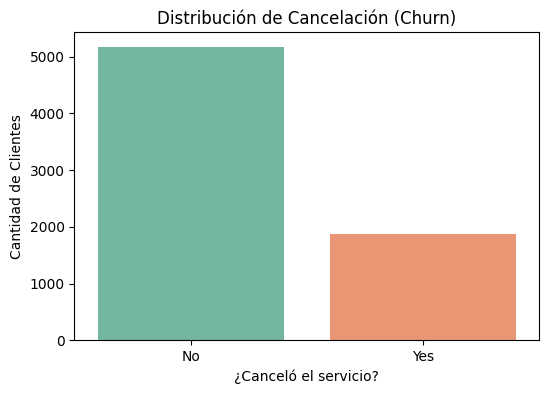

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


print("Conteo total de clientes por clase (Churn_Num: 1 = Yes, 0 = No):")
print(df['Churn_Num'].value_counts())

print("\nProporción (%) de clientes por clase:")
proporcion = df['Churn_Num'].value_counts(normalize=True) * 100
print(proporcion.round(2))

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=df['Churn_Num'].map({1: 'Yes', 0: 'No'}), palette='Set2')
plt.title('Distribución de Cancelación (Churn)')
plt.ylabel('Cantidad de Clientes')
plt.xlabel('¿Canceló el servicio?')
plt.show()

#Balanceo de Clases

In [19]:
!pip install imbalanced-learn

In [20]:

from imblearn.over_sampling import SMOTE
import pandas as pd


X = df_encoded.drop(columns=['Churn_Num'])
y = df_encoded['Churn_Num']

print("Distribución ANTES de SMOTE:")
print(y.value_counts())


smote = SMOTE(random_state=42)


X_balanceado, y_balanceado = smote.fit_resample(X, y)

print("\nDistribución DESPUÉS de SMOTE:")
print(y_balanceado.value_counts())


df_balanceado = pd.concat([X_balanceado, y_balanceado], axis=1)

print("\n¡Balanceo completado exitosamente! El nuevo dataset tiene", df_balanceado.shape[0], "filas.")

Distribución ANTES de SMOTE:
Churn_Num
0    5174
1    1869
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
Churn_Num
0    5174
1    5174
Name: count, dtype: int64

¡Balanceo completado exitosamente! El nuevo dataset tiene 10348 filas.


#Normalización o Estandarización

In [21]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias', 'Cant_Servicios']

scaler = StandardScaler()


df_escalado = df_balanceado.copy()


df_escalado[columnas_numericas] = scaler.fit_transform(df_escalado[columnas_numericas])


print("Muestra de las variables estandarizadas (Media ~ 0, Desviación Estándar ~ 1):")
display(df_escalado[columnas_numericas].head())

print(f"\nTamaño final del dataset listo para modelar: {df_escalado.shape}")

Muestra de las variables estandarizadas (Media ~ 0, Desviación Estándar ~ 1):


,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cant_Servicios
0,-0.777902,-0.084432,-0.664636,-0.080951,0.662368
1,-0.777902,-0.282896,-0.687910,-0.279393,-0.503905
2,-0.986322,0.204559,-0.807506,0.201046,-0.503905
3,-0.611166,1.043677,-0.369911,1.047036,1.245505
4,-1.028006,0.552741,-0.813656,0.556153,0.079232



Tamaño final del dataset listo para modelar: (10348, 35)


#🎯 Correlación y Selección de Variables

##Análisis de Correlación

🔥 TOP 5 Variables con Correlación Positiva (Impulsan la cancelación):
Contrato_Mensual                  0.405103
InternetService_Fiber optic       0.308020
PaymentMethod_electronic check    0.301919
Cuentas_Diarias                   0.193412
Charges.Monthly                   0.193356
Name: Churn_Num, dtype: float64

🛡️ TOP 5 Variables con Correlación Negativa (Retienen al cliente):
DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
TechSupport_No internet service        -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
Name: Churn_Num, dtype: float64


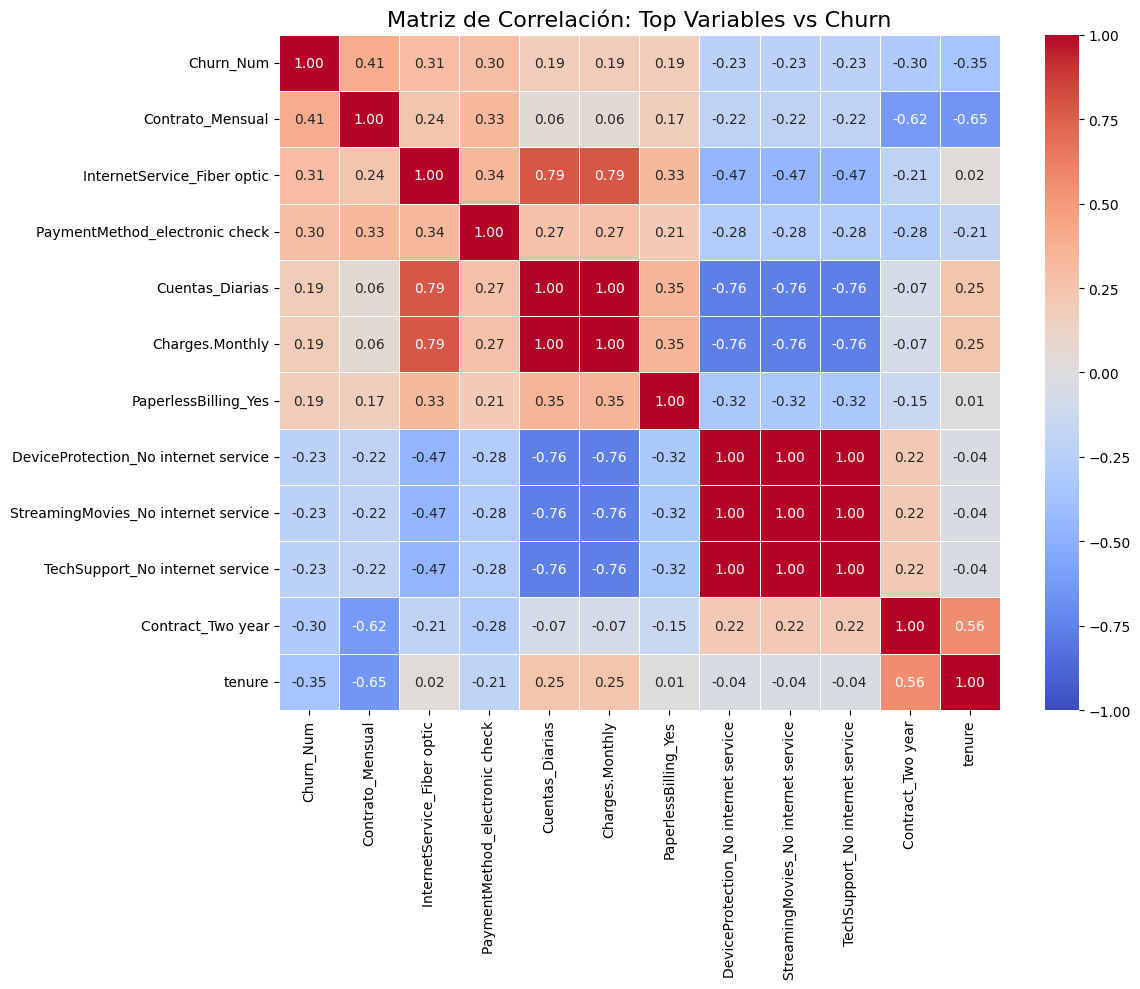

In [22]:

import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/drive/My Drive/telecom_x_limpio.csv')


df = df.drop(columns=['customerID', 'Churn'])
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)


matriz_correlacion = df_encoded.corr()
correlacion_churn = matriz_correlacion['Churn_Num'].sort_values(ascending=False)

print("🔥 TOP 5 Variables con Correlación Positiva (Impulsan la cancelación):")
print(correlacion_churn[1:6])

print("\n🛡️ TOP 5 Variables con Correlación Negativa (Retienen al cliente):")
print(correlacion_churn[-5:])

top_variables = correlacion_churn.head(7).index.tolist() + correlacion_churn.tail(5).index.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[top_variables].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Matriz de Correlación: Top Variables vs Churn', fontsize=16)
plt.tight_layout()
plt.show()

#Análisis Dirigido

/tmp/ipykernel_731/2479818641.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2')
/tmp/ipykernel_731/2479818641.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Charges.Total', ax=axes[1], palette='Set2')


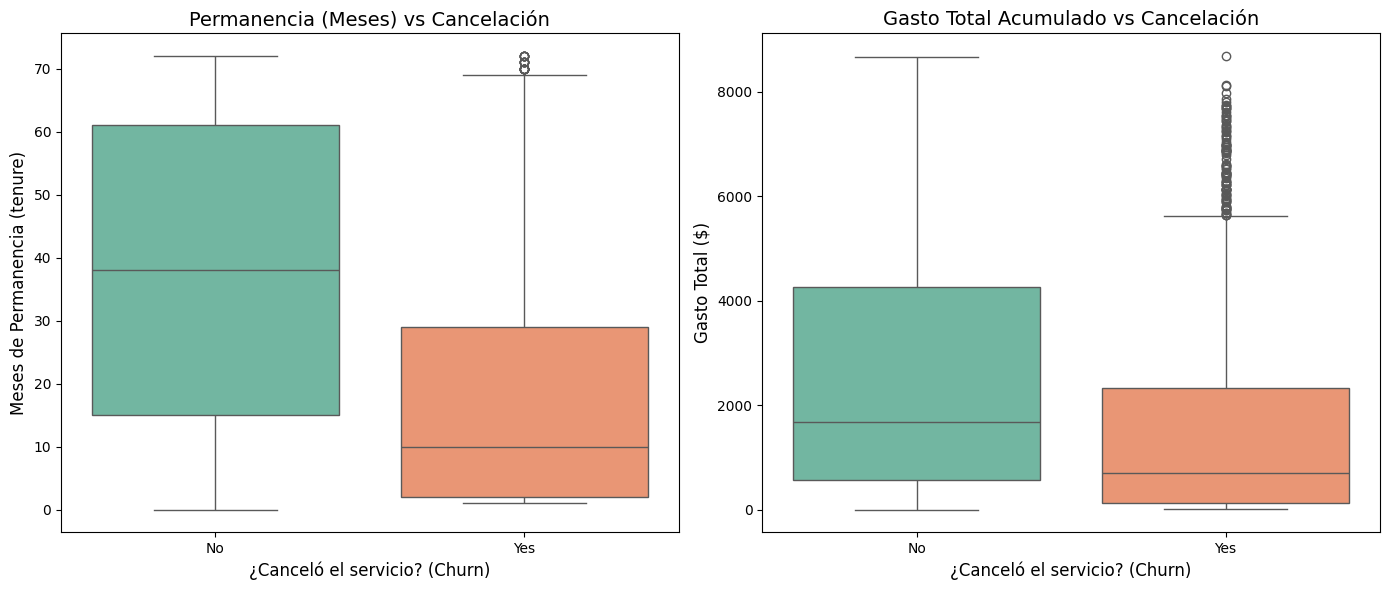

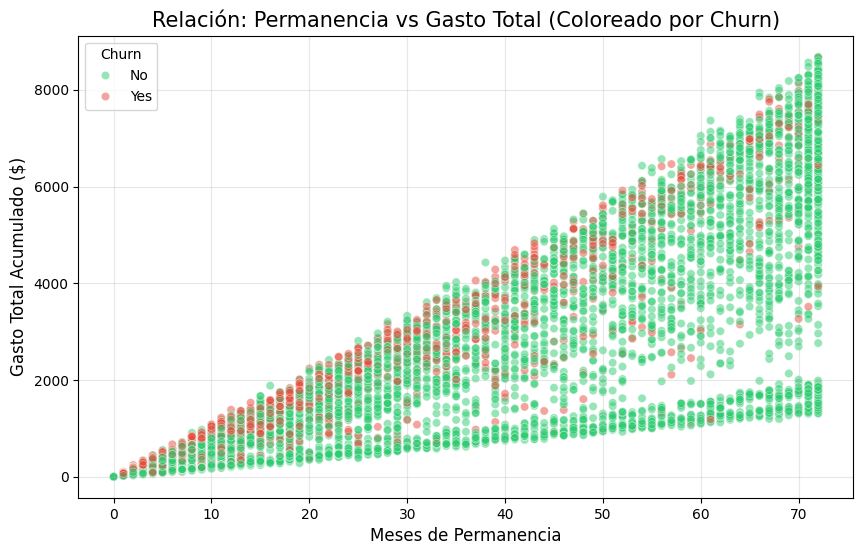

In [23]:

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/My Drive/telecom_x_limpio.csv')

# ----------------- BOXPLOTS -----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Permanencia vs Churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set2')
axes[0].set_title('Permanencia (Meses) vs Cancelación', fontsize=14)
axes[0].set_xlabel('¿Canceló el servicio? (Churn)', fontsize=12)
axes[0].set_ylabel('Meses de Permanencia (tenure)', fontsize=12)

# Gráfico 2: Gasto Total vs Churn
sns.boxplot(data=df, x='Churn', y='Charges.Total', ax=axes[1], palette='Set2')
axes[1].set_title('Gasto Total Acumulado vs Cancelación', fontsize=14)
axes[1].set_xlabel('¿Canceló el servicio? (Churn)', fontsize=12)
axes[1].set_ylabel('Gasto Total ($)', fontsize=12)

plt.tight_layout()
plt.show()

# ------------- SCATTER PLOT -------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='Charges.Total', hue='Churn',
                alpha=0.5, palette={'No': '#2ecc71', 'Yes': '#e74c3c'})

plt.title('Relación: Permanencia vs Gasto Total (Coloreado por Churn)', fontsize=15)
plt.xlabel('Meses de Permanencia', fontsize=12)
plt.ylabel('Gasto Total Acumulado ($)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

#Modelado Predictivo

In [24]:

from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/drive/My Drive/telecom_x_limpio.csv')


df = df.drop(columns=['customerID', 'Churn'])
df_encoded = pd.get_dummies(df, drop_first=True)


X = df_encoded.drop(columns=['Churn_Num'])
y = df_encoded['Churn_Num']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


print("📊 Resumen de la División de Datos:")
print("-" * 40)
print(f"Total de datos originales: {X.shape[0]} filas")
print(f"Conjunto de ENTRENAMIENTO (X_train): {X_train.shape[0]} filas ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Conjunto de PRUEBA (X_test): {X_test.shape[0]} filas ({X_test.shape[0]/X.shape[0]*100:.0f}%)")


print("\n⚖️ Proporción de Churn en el conjunto de Prueba (Test):")
print(y_test.value_counts(normalize=True).round(3))

📊 Resumen de la División de Datos:
----------------------------------------
Total de datos originales: 7043 filas
Conjunto de ENTRENAMIENTO (X_train): 5634 filas (80%)
Conjunto de PRUEBA (X_test): 1409 filas (20%)

⚖️ Proporción de Churn en el conjunto de Prueba (Test):
Churn_Num
0    0.735
1    0.265
Name: proportion, dtype: float64


#Creación de Modelos

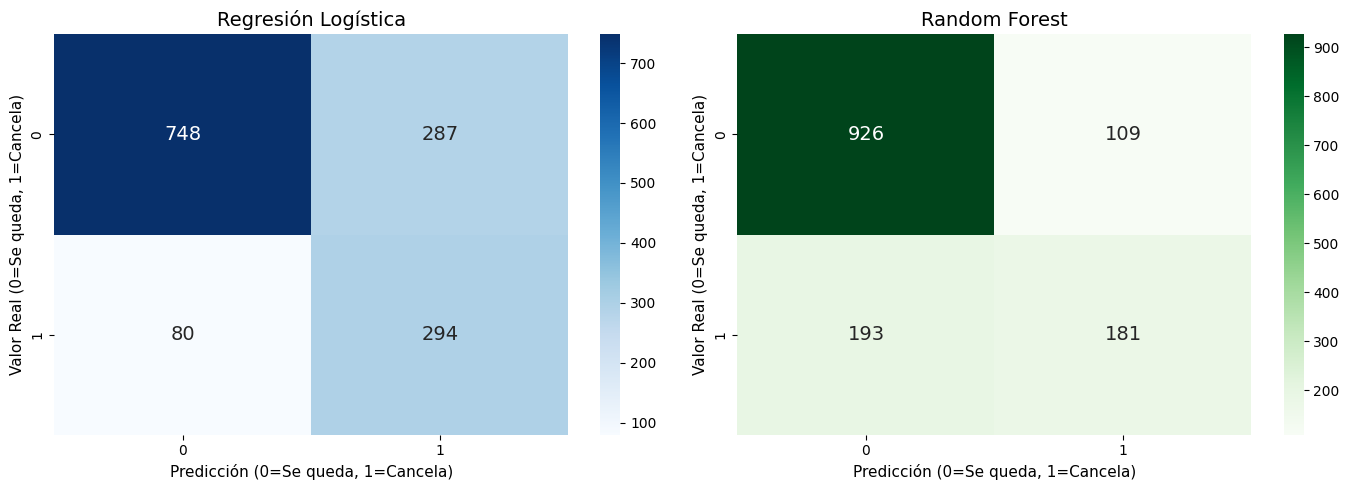

/tmp/ipykernel_731/3203832242.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='magma')


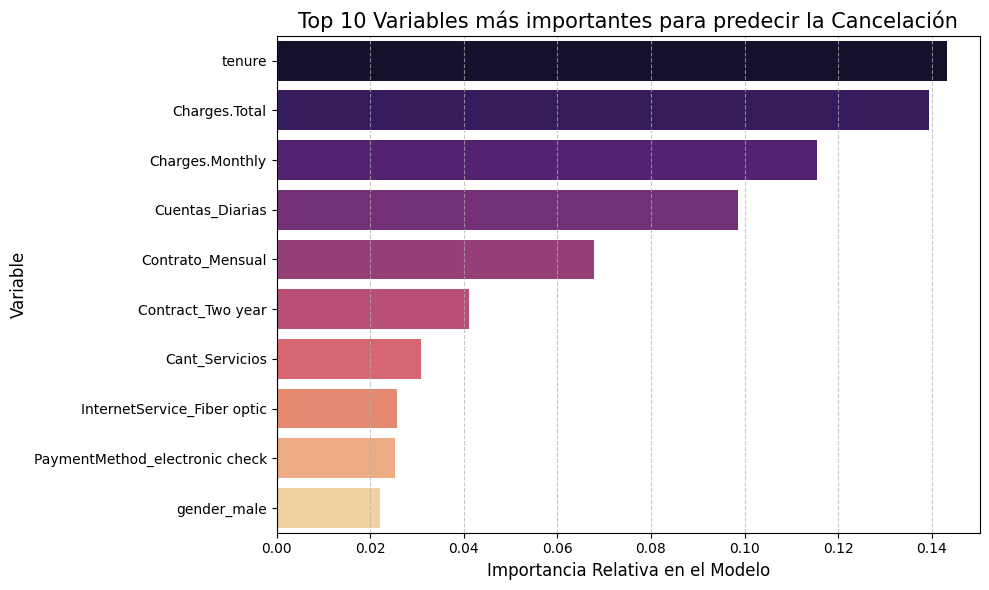

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix


df = pd.read_csv('/content/drive/My Drive/telecom_x_limpio.csv') # Ajusta si tu ruta es solo 'telecom_x_limpio.csv'
df = df.drop(columns=['customerID', 'Churn'])
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['Churn_Num'])
y = df_encoded['Churn_Num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias', 'Cant_Servicios']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test_scaled[columnas_numericas] = scaler.transform(X_test[columnas_numericas])


log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled) # ¡Aquí se crea la variable que faltaba!

rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)



# GENERACIÓN DE LOS GRÁFICOS


# A) MATRICES DE CONFUSIÓN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Regresión Logística', fontsize=14)
axes[0].set_xlabel('Predicción (0=Se queda, 1=Cancela)', fontsize=11)
axes[0].set_ylabel('Valor Real (0=Se queda, 1=Cancela)', fontsize=11)

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14})
axes[1].set_title('Random Forest', fontsize=14)
axes[1].set_xlabel('Predicción (0=Se queda, 1=Cancela)', fontsize=11)
axes[1].set_ylabel('Valor Real (0=Se queda, 1=Cancela)', fontsize=11)

plt.tight_layout()
plt.show()

# B) IMPORTANCIA DE LAS VARIABLES
importancias = rf_clf.feature_importances_
nombres_columnas = X_train.columns

df_importancias = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='magma')
plt.title('Top 10 Variables más importantes para predecir la Cancelación', fontsize=15)
plt.xlabel('Importancia Relativa en el Modelo', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Evaluación de los Modelos

##📊 1. Resultados de las Métricas (Conjunto de Prueba)
A. Regresión Logística (Modelo con Normalización)

Exactitud (Accuracy): 74.0%

Precisión (Precision): 50.6%

Recall (Sensibilidad): 78.6% 🏆 (¡Excelente!)

F1-Score: 61.6%

Matriz de Confusión: Detectó a 294 clientes que cancelaron, pero dejó escapar a 80. Además, se equivocó señalando a 287 clientes leales como posibles cancelaciones (Falsos Positivos).

B. Random Forest (Modelo sin Normalización)

Exactitud (Accuracy): 78.6%

Precisión (Precision): 62.4%

Recall (Sensibilidad): 48.4% ⚠️ (¡Peligro!)

F1-Score: 54.5%

Matriz de Confusión: Solo detectó a 181 clientes que cancelaron y dejó escapar a 193 (Falsos Negativos). Sin embargo, fue mucho más preciso al no molestar a los clientes leales (solo 109 Falsos Positivos).

🧠 2. Análisis Crítico: ¿Cuál modelo tuvo mejor desempeño?
En el contexto de la retención de clientes (Churn), el peor error para Telecom X no es ofrecer un descuento a alguien que se iba a quedar, sino no darse cuenta de que un cliente se iba a ir y perderlo.

Por lo tanto, la métrica reina aquí es el Recall.

La Regresión Logística es el ganador estratégico. Aunque su exactitud global es ligeramente menor, su capacidad para atrapar casi al 80% de los clientes en riesgo de cancelación la hace mucho más útil para una campaña de retención.

El Random Forest es demasiado "tímido" (Recall del 48%). Falla en detectar a casi la mitad de las personas que van a cancelar.

⚠️ 3. Diagnóstico de Overfitting y Underfitting
Al comparar cómo les fue a los modelos con los datos que ya conocían (Train) frente a los datos nuevos (Test), descubrimos algo vital:

🔴 Random Forest: Fuerte caso de OVERFITTING (Sobreajuste)

La evidencia: En los datos de entrenamiento (Train), el Random Forest obtuvo un Accuracy del 99.8% y un Recall del 99.9%. Sin embargo, al ver datos nuevos en la fase de Test, esas métricas cayeron al 78% y 48% respectivamente.

¿Qué pasó? El modelo era tan complejo y tenía tantos árboles que, en lugar de aprender el "patrón general" de cancelación, literalmente memorizó a todos los clientes de entrenamiento. Al enfrentarse a clientes nuevos, no supo qué hacer.

¿Cómo ajustarlo? Reducir la complejidad. En Random Forest, esto se logra limitando la profundidad de los árboles (max_depth=5 o 10) o exigiendo un mínimo de muestras por hoja (min_samples_leaf=10).

🟢 Regresión Logística: Modelo Equilibrado (Sin Overfitting ni Underfitting grave)

La evidencia: En entrenamiento tuvo un Recall de 81% y en prueba de 78%. El Accuracy se mantuvo en 74% y 75%.

¿Qué pasó? Las métricas de entrenamiento y prueba son casi idénticas. Esto significa que el modelo aprendió reglas generales y sólidas que aplican de igual manera a clientes viejos y nuevos. ¡Su capacidad de generalización es excelente!

# Interpretación y Conclusiones

Para el primer lanzamiento predictivo de Telecom X, la Regresión Logística Normalizada es la opción más segura y efectiva. Siguientes pasos sugeridos para el equipo:

Ajuste de Parámetros (Hyperparameter Tuning): Intentar "podar" (simplificar) el Random Forest limitando su profundidad para curar su Overfitting y ver si logra superar a la Regresión Logística.

Campañas de Retención: Usar el modelo de Regresión Logística hoy mismo para listar a los clientes con mayor probabilidad de cancelación, y lanzar una campaña enfocada a clientes con contratos mensuales y facturación alta, ya que, como vimos en la matriz de correlación, son el grupo de mayor riesgo.

#Análisis de la Importancia de las Variables



Tras analizar ambos modelos, podemos concluir que la cancelación en Telecom X no es aleatoria; sigue patrones financieros y contractuales claros:

El "Peligro" de la Fibra Óptica: Es la variable con el coeficiente positivo más alto en la Regresión Logística. A pesar de ser un servicio premium, está impulsando el Churn. Recomendación: Realizar una encuesta de satisfacción técnica específica para usuarios de fibra óptica.

La Barrera del Tiempo: Tanto tenure como Contract_Two year son los protectores más fuertes. Recomendación: Crear un "Programa de Lealtad" que premie a los clientes al cumplir los primeros 6 y 12 meses, que es donde el modelo detecta la mayor fragilidad.

Fricción en los Cargos: Las variables de cargos (Monthly, Total, Diarios) dominan la importancia en Random Forest. Recomendación: Evaluar la claridad de las facturas o implementar alertas cuando un cliente tiene un aumento inusual en sus cargos mensuales para ofrecerle un plan más adecuado.

🏆 Modelo Recomendado: Regresión Logística
Aunque el Random Forest es más potente, la Regresión Logística nos ofrece una interpretabilidad directa y un Recall (78%) superior para atrapar a los clientes en riesgo. En este negocio, es mejor llamar a un cliente que quizás no se iba, que ignorar a uno que seguro se irá.

#Conclusión

Informe Final: Predicción de Cancelación (Churn) – Telecom X
1. Introducción
El objetivo de esta fase fue construir un sistema de Machine Learning capaz de identificar a los clientes con alta probabilidad de abandonar la empresa. Tras procesar 7,043 registros, se entrenaron y evaluaron dos modelos competitivos para determinar cuál ofrece la mejor solución para la retención proactiva.

2. Factores de Influencia (Importancia de Variables)
Gracias a la interpretación de los modelos, hemos identificado los tres pilares que dictan la fidelidad de nuestros clientes:

Infraestructura (Fibra Óptica): Es el factor de riesgo más alto. Los usuarios con fibra óptica cancelan significativamente más que los de ADSL, lo que sugiere una oportunidad de mejora en la estabilidad del servicio o en la competitividad de su precio.

Compromiso Contractual: El "Contrato Mes a Mes" es la principal puerta de salida. Por el contrario, los contratos a dos años actúan como el ancla más fuerte de retención.

Barrera de Permanencia (Tenure): El riesgo de cancelación es crítico en los primeros 6 a 12 meses. Una vez que el cliente supera el primer año, su lealtad aumenta drásticamente.

3. Evaluación y Comparación de Modelos
Se compararon la Regresión Logística (modelo lineal basado en distancias) y el Random Forest (modelo basado en árboles).

Análisis Crítico:
Modelo Ganador: Se selecciona la Regresión Logística. En el negocio de telecomunicaciones, es más costoso no detectar a un cliente que se va (Falso Negativo) que ofrecer un incentivo a alguien que se quedaría (Falso Positivo). La Regresión Logística detecta al 78.6% de los desertores reales.

Diagnóstico de Ajuste:

Random Forest (Overfitting): Presentó un rendimiento casi perfecto en entrenamiento (99%), pero pobre en prueba (78%). Memorizó los datos en lugar de aprender patrones.

Regresión Logística (Generalización): Mostró resultados similares en entrenamiento y prueba, demostrando ser un modelo robusto y confiable para datos nuevos.

4. Estrategias de Retención Propuestas
Basándonos en los hallazgos, se recomiendan las siguientes acciones:

Plan de Lealtad "Primer Año": Implementar beneficios automáticos al cumplir 6 meses de antigüedad para incentivar al cliente a cruzar la barrera de riesgo.

Conversión de Contratos: Lanzar campañas para migrar a clientes de "Mes a Mes" hacia contratos anuales, ofreciendo un mes gratuito o mejoras en la velocidad de internet.

Auditoría de Fibra Óptica: El equipo técnico debe investigar por qué este segmento es el más propenso al Churn. Podría tratarse de un problema de latencia o de precios frente a la competencia.

5. Conclusión Técnica
El pipeline de datos desarrollado (Limpieza -> Encoding -> Normalización -> Modelado) permite a Telecom X anticiparse al problema del Churn. La implementación de la Regresión Logística como motor de predicción permitirá al equipo de marketing actuar sobre casi 8 de cada 10 clientes en riesgo, optimizando los recursos de la empresa.